In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import json

In [2]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
"latitude": -33.45, # Latitud de Santiago
"longitude": -70.65, # Longitud de Santiago
"current_weather": True
}
response = requests.get(url, params=params)
response.raise_for_status() # lanza excepcion si codigo >= 400
data = response.json()
print(f"Codigo de estado : {response.status_code}")
print(f"URL final : {response.url}")
print(f"Clima actual : {data['current_weather']}")

Codigo de estado : 200
URL final : https://api.open-meteo.com/v1/forecast?latitude=-33.45&longitude=-70.65&current_weather=True
Clima actual : {'time': '2026-06-10T16:15', 'interval': 900, 'temperature': 9.8, 'windspeed': 3.3, 'winddirection': 9, 'is_day': 1, 'weathercode': 51}


In [3]:
# Explorar el JSON antes de procesarlo
print("Claves principales:", list(data.keys()))
# Ver el JSON formateado
print(json.dumps(data))#preguntar

Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_weather_units', 'current_weather']
{"latitude": -33.427067, "longitude": -70.64276, "generationtime_ms": 0.11932849884033203, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 554.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\u00b0C", "windspeed": "km/h", "winddirection": "\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2026-06-10T16:15", "interval": 900, "temperature": 9.8, "windspeed": 3.3, "winddirection": 9, "is_day": 1, "weathercode": 51}}


In [4]:
#respuesta de desarrollo acrivida 1
#1.al poner un timeout tan bajo como 0 o 0,00001 la solicitud no alcanzara a completarse antes de que expire el tiempo de espera.
#2.response.text devuelve el contenido de la respuesta como cadena de texto y response.json interpreta el contenido y lo convierte automaticamente a objetos de python (diccionario o lista)
#3.los parametros se agregan despues del simbolo ? y cada parametro es representado como una clave valor para asi ser separados por & esto lo que hace es que el diccionario enviado en params se codifica de manera automatica en la url como una cadena de consulta


In [5]:
def get_seguro(url, params=None, timeout=10):
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondio en {timeout}s")
    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")
        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Limite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print("No autorizado. Verificar API key.")
    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexion o host invalido")
    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")
    return None

In [6]:
# Caso 1: URL valida — debe retornar datos
r1 = get_seguro(
    "https://api.open-meteo.com/v1/forecast",
    params={"latitude": -33.45, "longitude": -70.65, "current_weather": True}
)
print("Caso 1 (valido):", r1["current_weather"] if r1 else "None")
# Caso 2: Endpoint inexistente — debe mostrar error 404
r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2 (404):", r2)
# Caso 3: Timeout muy bajo — debe mostrar error de timeout
r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3 (timeout):", r3)

Caso 1 (valido): {'time': '2026-06-10T16:15', 'interval': 900, 'temperature': 9.8, 'windspeed': 3.3, 'winddirection': 9, 'is_day': 1, 'weathercode': 51}
[ERROR] HTTP 404: Not Found
Endpoint no encontrado. Revisa la URL.
Caso 2 (404): None
[ERROR] Timeout: la API no respondio en 1e-05s
Caso 3 (timeout): None


In [7]:
#paso 3 actividad 2
#A) Es obligatorio usar time out por que evita que el programa quede esperando infinitamente una respuesta del sevidor la ejecucion continuará despues de un tiempo definido y podrá manejar el error correctamente.
#B)raise_for_status() verifica el codigo de estado HTTP de la respuesta. Si el servidor devuelve un error (por ejemplo, 404 o 500) lanza una excepcion HTTPError permitiendo detectar y manejar el problema.
#C)Timeout: cuando el servidor tarda demasiado en responder, HTTPError: cuando la respuesta HTTP indica un error (404, 401, 500, etc.), ConnectionError: cuando no hay conexión a Internet o el servidor no está disponible, RequestException: para capturar cualquier otro error relacionado con la peticion.

In [8]:
#preguntas de reflexion 
#¿Por qué es peligroso un script sin timeout= que consume APIs externas?
#R:Porque si la API no responde o la conexion se bloquea, el programa puede quedar esperando indefinidamente, consumiendo recursos y deteniendo la ejecución.
#¿Qué estrategia usarías si la API retorna 429 de forma intermitente?
#R:Implementaria reintentos con pausas time.sleep entre cada intento, aumentando gradualmente el tiempo de espera para respetar el limite de peticiones de la API.
#¿Qué diferencia hay entre ConnectionError y Timeout en términos de causa?
#R:ConnectionError: ocurre cuando no se puede establecer conexion con el servidor (sin Internet, DNS incorrecto, servidor caido, etc.), Timeout: ocurre cuando la conexion si se establece, pero la respuesta tarda mas de lo permitido.

In [9]:
def consumir_paginado(url, limite=20, max_paginas=20):

    todos = []
    pagina = 1
    while pagina <= max_paginas:
        resultado = get_seguro(url, params={"_page": pagina, "_limit": limite})
        if resultado is None: # error en la peticion
            break
        if not resultado: # lista vacia = no hay mas datos
            print(f"Fin de datos en pagina {pagina}")
            break
        todos.extend(resultado)
        print(f" Pagina {pagina:2d}: {len(resultado):3d} registros | Total:{len(todos)}")
        pagina += 1
        time.sleep(0.1) # cortesia al servidor
    return todos

In [10]:
print("Descargando posts...")
posts = consumir_paginado("https://jsonplaceholder.typicode.com/posts",limite=20)
df_posts = pd.DataFrame(posts)

print(f"\nForma del DataFrame: {df_posts.shape}")
print("\nPrimeras filas:")
print(df_posts.head())
print("\nTipos de datos:")
print(df_posts.dtypes)

Descargando posts...
 Pagina  1:  20 registros | Total:20
 Pagina  2:  20 registros | Total:40
 Pagina  3:  20 registros | Total:60
 Pagina  4:  20 registros | Total:80
 Pagina  5:  20 registros | Total:100
Fin de datos en pagina 6

Forma del DataFrame: (100, 4)

Primeras filas:
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt s

In [11]:
# Estadisticas por userId
resumen = df_posts.groupby("userId").agg(
    total_posts = ("id", "count"),
    largo_promedio = ("body", lambda x: x.str.len().mean().round(1))
).reset_index()

print(resumen)

# Exportar a CSV
df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)
print("\nArchivos CSV exportados correctamente.")

   userId  total_posts  largo_promedio
0       1           10           164.5
1       2           10           162.9
2       3           10           153.8
3       4           10           182.3
4       5           10           162.5
5       6           10           147.0
6       7           10           163.5
7       8           10           160.6
8       9           10           154.6
9      10           10           154.7

Archivos CSV exportados correctamente.


In [12]:
#preguntas  reflexion actividad 3
#¿Que ocurre si la API devuelve una lista vacía en la primera página?
#R: La condicion if not resultado: se cumple, se muestra el mensaje "Fin de datos en pagina 1" y el ciclo termina inmediatamente. La funcion retorna una lista vacia.
#¿Para qué sirve el parámetro max_paginas en la función?
#R: Sirve para limitar la cantidad maxima de paginas que se descargaran. Esto evita ciclos muy largos o infinitos.
#¿Qué ventaja ofrece pd.DataFrame(lista_de_dicts) frente a construir el DataFrame manualmente?
#R: Permite crear el DataFrame de forma automatica a partir de una lista de diccionarios, generando las columnas y filas directamente.

In [13]:
def obtener_clima(lat, lon, dias=3):
    """Retorna DataFrame con temperatura horaria para una ubicacion."""
    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone": "America/Santiago"
        }
    )
    if data is None:
        return None
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df
CIUDADES = {
    "Santiago": (-33.45, -70.65),
    "Concepcion": (-36.82, -73.04),
    "Antofagasta":(-23.65, -70.40),
    }
datos = {}
for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3)
print("Extraccion completa.")

Extrayendo Santiago...
[ERROR] Timeout: la API no respondio en 10s
Extrayendo Concepcion...
Extrayendo Antofagasta...
Extraccion completa.


In [14]:
frames = []
for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"] = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

resumen_diario = df_all.groupby(["ciudad", "fecha"]).agg(
    temp_max=("temperature_2m", "max"),
    temp_min=("temperature_2m", "min"),
    temp_prom=("temperature_2m", "mean"),
).round(1).reset_index()

print(resumen_diario)

        ciudad       fecha  temp_max  temp_min  temp_prom
0  Antofagasta  2026-06-10      17.8      13.8       15.6
1  Antofagasta  2026-06-11      18.6      14.6       16.1
2  Antofagasta  2026-06-12      18.7      14.1       16.3
3   Concepcion  2026-06-10      13.4       7.4       10.8
4   Concepcion  2026-06-11      11.8       4.7        8.4
5   Concepcion  2026-06-12      11.6       8.5       10.4


CSV exportado: resumen_clima.csv


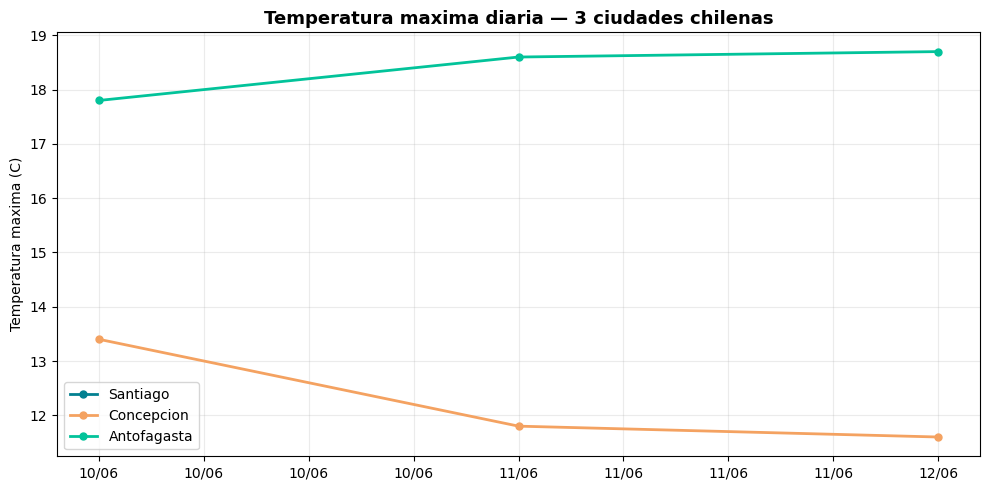

Grafico guardado: comparacion_temp.png


In [15]:
# Load
resumen_diario.to_csv("resumen_clima.csv", index=False)
print("CSV exportado: resumen_clima.csv")
# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
colores = ["#028090", "#F4A261", "#02C39A"]
for (ciudad, color) in zip(CIUDADES.keys(), colores):
    df_c = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])
    ax.plot(fechas, df_c["temp_max"], marker="o", label=ciudad,
        color=color, linewidth=2, markersize=5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_title("Temperatura maxima diaria — 3 ciudades chilenas",
            fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatura maxima (C)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: comparacion_temp.png")

In [16]:
#preguntas de reflexion
1.#¿Por que es importante llamar plt.tight_layout() antes de savefig()?
    #R: Porque ajusta automaticamente los margenes y espacios del grafico para evitar que titulos, etiquetas o leyendas queden cortados al guardar la imagen.
2.#¿Como modificarías el código para agregar una cuarta ciudad sin cambiar la estructura principal?
    #R: Solo agregaria una nueva entrada al diccionario por ejemplo estas : CIUDADES = {"Santiago": (-33.45, -70.65),"Concepcion": (-36.82, -73.04),"Antofagasta": (-23.65, -70.40),"Valparaiso": (-33.05, -71.62)}
3.#Describe el pipeline ETL que implementaste en esta actividad con tus propias palabras.
    #R:Primero extraje los datos climaticos desde la API para varias ciudades. Luego transforme los datos creando DataFrames, agregando las columnas de ciudad y fecha, y calculando temperaturas maximas, minimas y promedio por dia. Finalmente cargue los resultados exportandolos a un archivo CSV y generando un grafico comparativo para visualizar la informacion.

3.0